# Disneyland Reviews: Complete EDA & Actionable Insights

Comprehensive exploratory data analysis to uncover patterns and drive customer experience improvements.

## 📋 Table of Contents
1. [Setup & Data Loading](#setup)
2. [Metadata Overview](#metadata-overview)
3. [Rating & Sentiment Analysis](#rating-sentiment)
4. [Temporal Analysis (Year-Month)](#temporal)
5. [Geographic Analysis](#geographic)
6. [Branch Comparison](#branch-comparison)
7. [LLM-Based Text Analysis](#llm-analysis)
8. [Key Insights & Recommendations](#insights)
9. [Action Items](#action-items)

---
## Setup & Data Loading {#setup}

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, str(Path.cwd().parent / 'src'))
from rag.config import DATA_PATH

print('Loading Disneyland reviews dataset...')
df = pd.read_csv(DATA_PATH, encoding='latin-1')
print(f'✓ Loaded {len(df):,} reviews')
print(f'Columns: {list(df.columns)}')
print(f'\nDataset overview:')
print(df.info())

16:08:26 - LiteLLM:WARNING: common_utils.py:979 - litellm: could not pre-load bedrock-runtime response stream shape — Bedrock event-stream decoding will be unavailable. Error: No module named 'botocore'
16:08:26 - LiteLLM:WARNING: common_utils.py:24 - litellm: could not pre-load sagemaker-runtime response stream shape — SageMaker event-stream decoding will be unavailable. Error: No module named 'botocore'


Loading Disneyland reviews dataset...
✓ Loaded 42,656 reviews
Columns: ['Review_ID', 'Rating', 'Year_Month', 'Reviewer_Location', 'Review_Text', 'Branch']

Dataset overview:
<class 'pandas.DataFrame'>
RangeIndex: 42656 entries, 0 to 42655
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Review_ID          42656 non-null  int64
 1   Rating             42656 non-null  int64
 2   Year_Month         42656 non-null  str  
 3   Reviewer_Location  42656 non-null  str  
 4   Review_Text        42656 non-null  str  
 5   Branch             42656 non-null  str  
dtypes: int64(2), str(4)
memory usage: 2.0 MB
None


---
## Metadata Overview {#metadata-overview}

Basic statistics and data quality checks.

In [2]:
print('Dataset Quality Metrics:')
print(f'Total reviews: {len(df):,}')
print(f'Missing values:\n{df.isnull().sum()}')
print(f'\nBranches: {df["Branch"].nunique()}')
print(df['Branch'].value_counts())
print(f'\nReviewer locations: {df["Reviewer_Location"].nunique()}')
print(f'Date range: {df["Year_Month"].min()} to {df["Year_Month"].max()}')

Dataset Quality Metrics:
Total reviews: 42,656
Missing values:
Review_ID            0
Rating               0
Year_Month           0
Reviewer_Location    0
Review_Text          0
Branch               0
dtype: int64

Branches: 3
Branch
Disneyland_California    19406
Disneyland_Paris         13630
Disneyland_HongKong       9620
Name: count, dtype: int64

Reviewer locations: 162
Date range: 2010-10 to missing


---
## Rating & Sentiment Analysis {#rating-sentiment}

Distribution of ratings and sentiment patterns across the dataset.

In [3]:
print('Rating Distribution:')
print(df['Rating'].value_counts().sort_index())
print(f'\nAverage rating: {df["Rating"].mean():.2f}/5')
print(f'Median rating: {df["Rating"].median():.1f}/5')
print(f'Std deviation: {df["Rating"].std():.2f}')

# Sentiment breakdown
positive = (df['Rating'] >= 4).sum()
neutral = (df['Rating'] == 3).sum()
negative = (df['Rating'] <= 2).sum()
print(f'\nSentiment Breakdown:')
print(f'Positive (4-5): {positive:,} ({positive/len(df)*100:.1f}%)')
print(f'Neutral (3): {neutral:,} ({neutral/len(df)*100:.1f}%)')
print(f'Negative (1-2): {negative:,} ({negative/len(df)*100:.1f}%)')

Rating Distribution:
Rating
1     1499
2     2127
3     5109
4    10775
5    23146
Name: count, dtype: int64

Average rating: 4.22/5
Median rating: 5.0/5
Std deviation: 1.06

Sentiment Breakdown:
Positive (4-5): 33,921 (79.5%)
Neutral (3): 5,109 (12.0%)
Negative (1-2): 3,626 (8.5%)


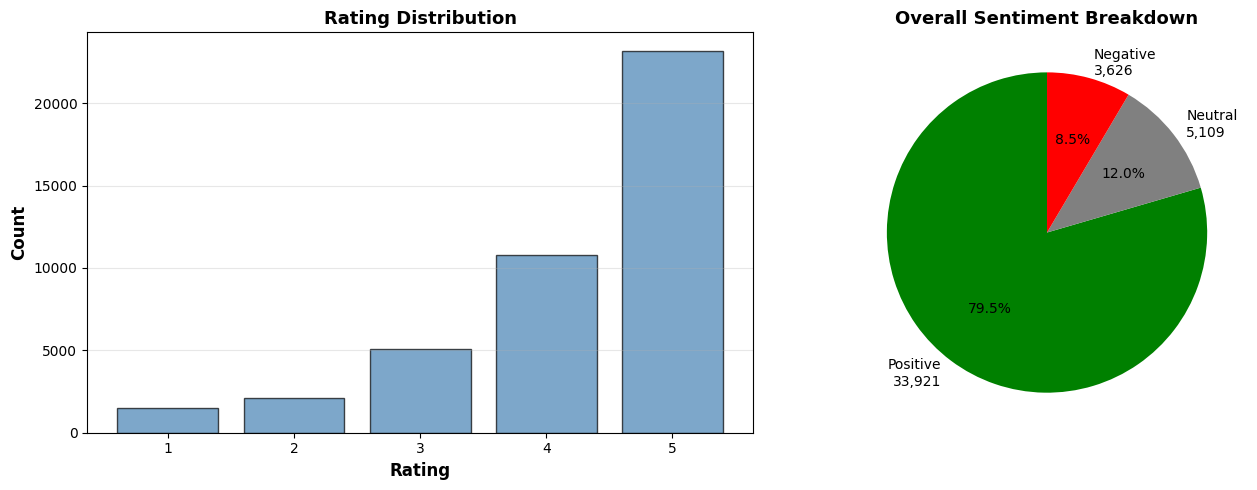

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rating distribution
ax1 = axes[0]
rating_counts = df['Rating'].value_counts().sort_index()
ax1.bar(rating_counts.index, rating_counts.values, color='steelblue', alpha=0.7, edgecolor='black')
ax1.set_xlabel('Rating', fontsize=12, fontweight='bold')
ax1.set_ylabel('Count', fontsize=12, fontweight='bold')
ax1.set_title('Rating Distribution', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Sentiment breakdown
ax2 = axes[1]
sentiment_data = [positive, neutral, negative]
sentiment_labels = [f'Positive\n{positive:,}', f'Neutral\n{neutral:,}', f'Negative\n{negative:,}']
colors = ['green', 'gray', 'red']
ax2.pie(sentiment_data, labels=sentiment_labels, colors=colors, autopct='%1.1f%%', startangle=90)
ax2.set_title('Overall Sentiment Breakdown', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

---
## Temporal Analysis (Year-Month) {#temporal}

How reviews and ratings have changed over time.

In [5]:
# Convert to datetime
df['YearMonth'] = pd.to_datetime(df['Year_Month'], format='%Y-%m', errors='coerce')
df_valid_dates = df.dropna(subset=['YearMonth'])

print(f'Date range: {df_valid_dates["YearMonth"].min()} to {df_valid_dates["YearMonth"].max()}')
print(f'Total months covered: {(df_valid_dates["YearMonth"].max() - df_valid_dates["YearMonth"].min()).days / 30:.0f} months')

# Yearly aggregation
df_valid_dates['Year'] = df_valid_dates['YearMonth'].dt.year
yearly_stats = df_valid_dates.groupby('Year').agg({
    'Review_ID': 'count',
    'Rating': ['mean', 'std']
}).round(2)
yearly_stats.columns = ['Count', 'Avg Rating', 'Std Dev']
print('\nYearly Statistics:')
print(yearly_stats)

Date range: 2010-03-01 00:00:00 to 2019-05-01 00:00:00
Total months covered: 112 months

Yearly Statistics:
      Count  Avg Rating  Std Dev
Year                            
2010    143        4.17     1.22
2011   1984        4.21     1.09
2012   4342        4.29     0.99
2013   4717        4.22     1.06
2014   5301        4.24     1.04
2015   6979        4.26     1.03
2016   6599        4.23     1.03
2017   5195        4.24     1.06
2018   3997        4.14     1.14
2019    786        4.11     1.18


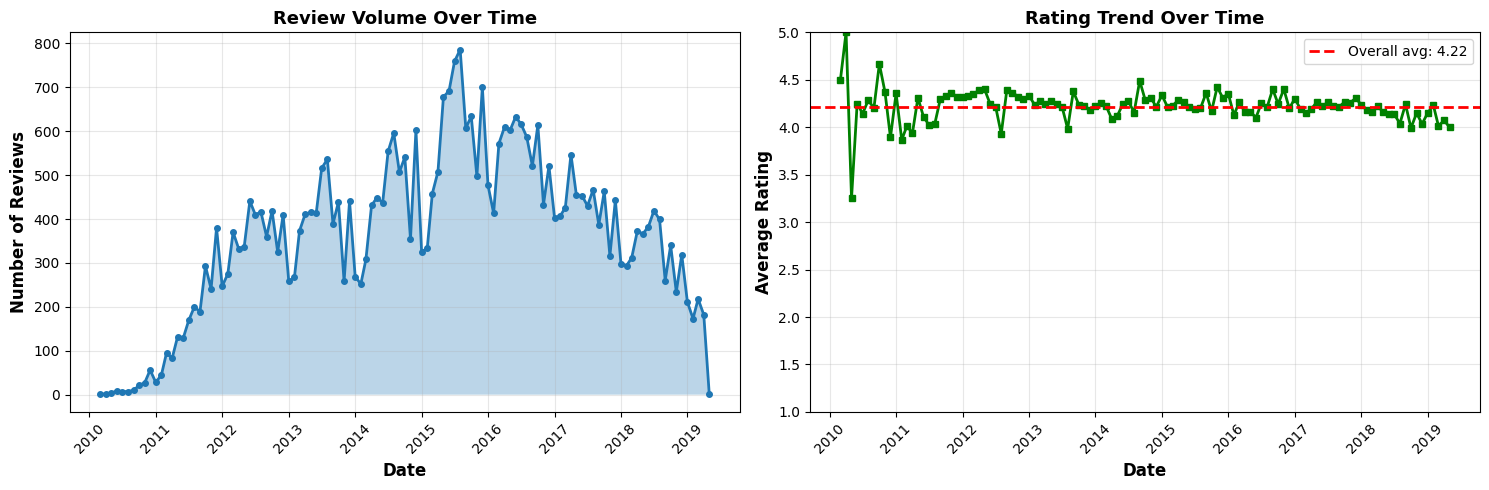

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Review volume over time
ax1 = axes[0]
reviews_by_month = df_valid_dates.groupby('YearMonth').size()
ax1.plot(reviews_by_month.index, reviews_by_month.values, marker='o', linestyle='-', linewidth=2, markersize=4)
ax1.fill_between(reviews_by_month.index, reviews_by_month.values, alpha=0.3)
ax1.set_xlabel('Date', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Reviews', fontsize=12, fontweight='bold')
ax1.set_title('Review Volume Over Time', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

# Rating trend
ax2 = axes[1]
avg_rating_by_month = df_valid_dates.groupby('YearMonth')['Rating'].mean()
ax2.plot(avg_rating_by_month.index, avg_rating_by_month.values, marker='s', linestyle='-', linewidth=2, markersize=4, color='green')
ax2.axhline(y=df['Rating'].mean(), color='red', linestyle='--', label=f'Overall avg: {df["Rating"].mean():.2f}', linewidth=2)
ax2.set_xlabel('Date', fontsize=12, fontweight='bold')
ax2.set_ylabel('Average Rating', fontsize=12, fontweight='bold')
ax2.set_title('Rating Trend Over Time', fontsize=13, fontweight='bold')
ax2.set_ylim([1, 5])
ax2.grid(True, alpha=0.3)
ax2.legend()
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

---
## Geographic Analysis {#geographic}

How different visitor locations rate the parks.

In [7]:
print('Top 15 Reviewer Locations:')
top_locations = df['Reviewer_Location'].value_counts().head(15)
print(top_locations)

# Rating by location
top_10_locations = df['Reviewer_Location'].value_counts().head(10).index
location_ratings = df[df['Reviewer_Location'].isin(top_10_locations)].groupby('Reviewer_Location')['Rating'].agg(['mean', 'count']).sort_values('mean', ascending=False)
location_ratings.columns = ['Avg Rating', 'Reviews']
print('\nAverage Rating by Top Locations:')
print(location_ratings.round(2))

Top 15 Reviewer Locations:
Reviewer_Location
United States           14551
United Kingdom           9751
Australia                4679
Canada                   2235
India                    1511
Philippines              1070
Singapore                1037
New Zealand               756
Malaysia                  588
Hong Kong                 554
Indonesia                 530
Ireland                   487
United Arab Emirates      350
Netherlands               253
France                    243
Name: count, dtype: int64

Average Rating by Top Locations:
                   Avg Rating  Reviews
Reviewer_Location                     
India                    4.44     1511
Philippines              4.40     1070
New Zealand              4.38      756
United States            4.32    14551
Australia                4.31     4679
Canada                   4.30     2235
Malaysia                 4.22      588
United Kingdom           4.05     9751
Singapore                4.03     1037
Hong Kong       

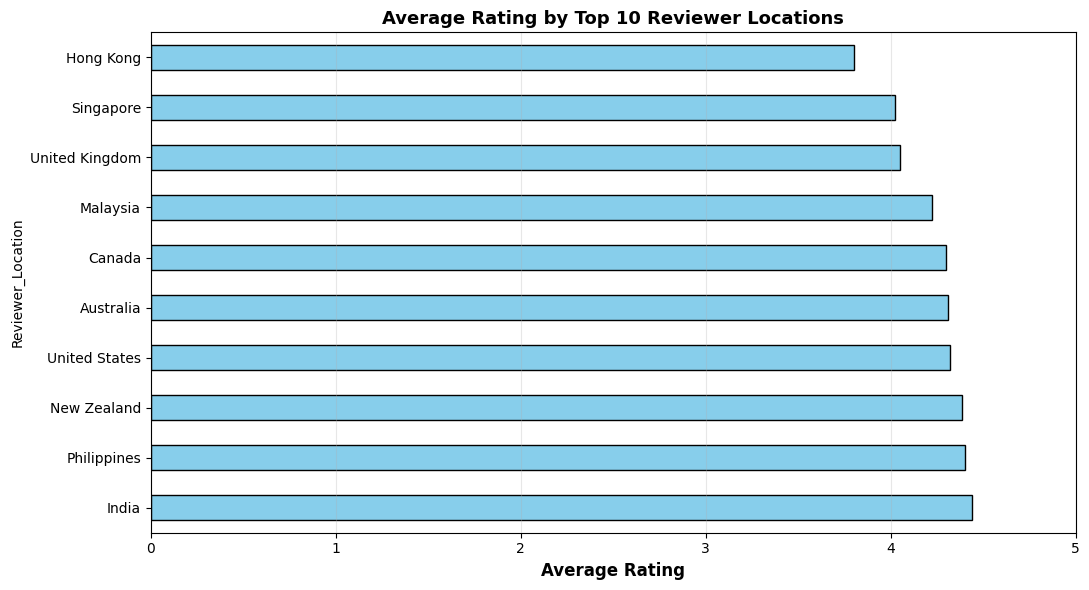

In [8]:
fig, ax = plt.subplots(figsize=(11, 6))
location_ratings['Avg Rating'].plot(kind='barh', ax=ax, color='skyblue', edgecolor='black')
ax.set_xlabel('Average Rating', fontsize=12, fontweight='bold')
ax.set_title('Average Rating by Top 10 Reviewer Locations', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.set_xlim([0, 5])
plt.tight_layout()
plt.show()

---
## Branch Comparison {#branch-comparison}

Performance and sentiment across Disneyland locations.

In [9]:
branch_stats = df.groupby('Branch').agg({
    'Rating': ['mean', 'std', 'count'],
    'Reviewer_Location': 'nunique',
    'Review_Text': lambda x: x.str.len().mean()
}).round(2)
branch_stats.columns = ['Avg Rating', 'Std Dev', 'Reviews', 'Unique Locations', 'Avg Text Length']

print('Branch Performance Summary:')
print(branch_stats)

# Sentiment by branch
for branch in df['Branch'].unique():
    branch_df = df[df['Branch'] == branch]
    pos = (branch_df['Rating'] >= 4).sum()
    neg = (branch_df['Rating'] <= 2).sum()
    print(f'\n{branch}:')
    print(f'  Positive: {pos/len(branch_df)*100:.1f}%')
    print(f'  Negative: {neg/len(branch_df)*100:.1f}%')

Branch Performance Summary:
                       Avg Rating  Std Dev  Reviews  Unique Locations  \
Branch                                                                  
Disneyland_California        4.41     0.98    19406               111   
Disneyland_HongKong          4.20     0.93     9620               117   
Disneyland_Paris             3.96     1.21    13630               133   

                       Avg Text Length  
Branch                                  
Disneyland_California           618.58  
Disneyland_HongKong             553.49  
Disneyland_Paris                909.37  

Disneyland_HongKong:
  Positive: 80.5%
  Negative: 5.3%

Disneyland_California:
  Positive: 85.0%
  Negative: 6.4%

Disneyland_Paris:
  Positive: 71.0%
  Negative: 13.7%


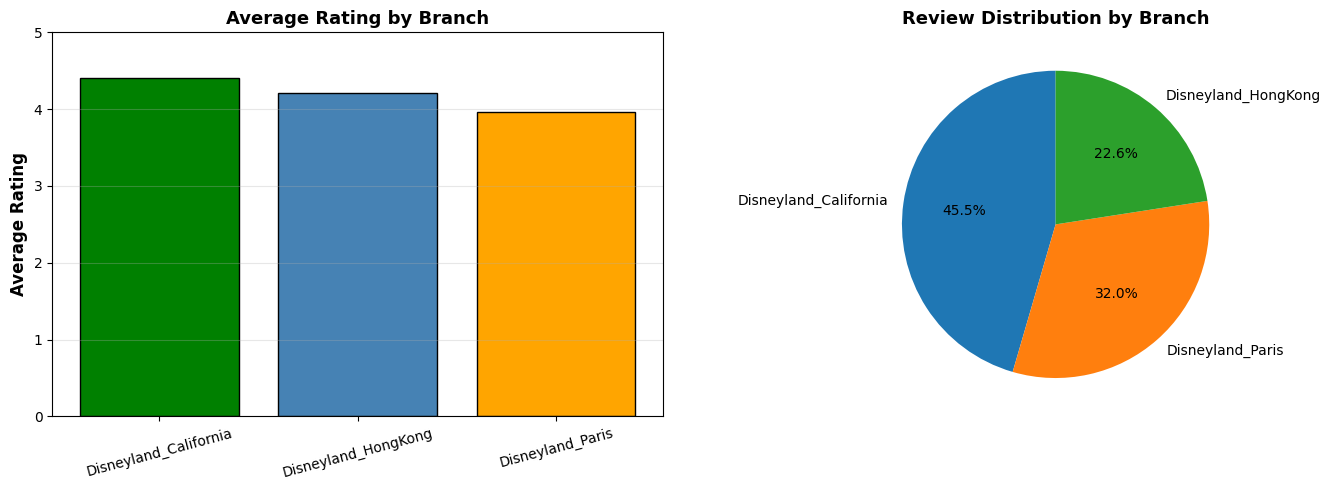

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average rating by branch
ax1 = axes[0]
branch_avg = df.groupby('Branch')['Rating'].mean().sort_values(ascending=False)
ax1.bar(range(len(branch_avg)), branch_avg.values, color=['green', 'steelblue', 'orange'], edgecolor='black')
ax1.set_xticks(range(len(branch_avg)))
ax1.set_xticklabels(branch_avg.index, rotation=15)
ax1.set_ylabel('Average Rating', fontsize=12, fontweight='bold')
ax1.set_title('Average Rating by Branch', fontsize=13, fontweight='bold')
ax1.set_ylim([0, 5])
ax1.grid(axis='y', alpha=0.3)

# Review count by branch
ax2 = axes[1]
branch_counts = df['Branch'].value_counts()
ax2.pie(branch_counts.values, labels=branch_counts.index, autopct='%1.1f%%', startangle=90)
ax2.set_title('Review Distribution by Branch', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

---
## LLM-Based Text Analysis {#llm-analysis}

Extract themes, pain points, and highlights from review text.

In [11]:
import os
from langchain_litellm import ChatLiteLLM
from rag.config import LLM_MODEL_NAME
import json

proxy_url = os.getenv('LITELLM_PROXY_URL', 'https://litellm.gke-prod.linnovate.net')
api_key = os.getenv('LITELLM_MASTER_KEY')

llm = ChatLiteLLM(
    model=LLM_MODEL_NAME,
    api_base=proxy_url,
    api_key=api_key,
    timeout=120,
)

print('LLM initialized for text analysis')

LLM initialized for text analysis


In [12]:
# Stratified sample: 100 reviews across branches and ratings
np.random.seed(42)
sample_size = 100

samples = []
for branch in df['Branch'].unique():
    branch_df = df[df['Branch'] == branch]
    branch_sample = branch_df.groupby('Rating', group_keys=False).apply(
        lambda x: x.sample(n=min(len(x), max(1, int(sample_size/3 * len(x) / len(branch_df)))), random_state=42)
    )
    samples.append(branch_sample)

sample_df = pd.concat(samples, ignore_index=True).drop_duplicates(subset=['Review_ID'])
print(f'Sample size: {len(sample_df)} reviews')
print('\nSample composition:')
print(sample_df['Branch'].value_counts())

Sample size: 94 reviews

Sample composition:
Branch
Disneyland_HongKong      32
Disneyland_California    31
Disneyland_Paris         31
Name: count, dtype: int64


In [15]:
df.head(10)

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch,YearMonth
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong,2019-04-01
1,670682799,4,2019-5,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong,2019-05-01
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong,2019-04-01
3,670607911,4,2019-4,Australia,HK Disneyland is a great compact park. Unfortu...,Disneyland_HongKong,2019-04-01
4,670607296,4,2019-4,United Kingdom,"the location is not in the city, took around 1...",Disneyland_HongKong,2019-04-01
5,670591897,3,2019-4,Singapore,"Have been to Disney World, Disneyland Anaheim ...",Disneyland_HongKong,2019-04-01
6,670585330,5,2019-4,India,Great place! Your day will go by and you won't...,Disneyland_HongKong,2019-04-01
7,670574142,3,2019-3,Malaysia,Think of it as an intro to Disney magic for th...,Disneyland_HongKong,2019-03-01
8,670571027,2,2019-4,Australia,"Feel so let down with this place,the Disneylan...",Disneyland_HongKong,2019-04-01
9,670570869,5,2019-3,India,I can go on talking about Disneyland. Whatever...,Disneyland_HongKong,2019-03-01


In [13]:
def analyze_review(review_text, rating, branch, location):
    prompt = f"""Analyze this review (Rating {rating}/5, {branch}, from {location}).

Review: {review_text[:400]}

Return JSON with:
- sentiment: positive, neutral, or negative
- issues: list of problems mentioned
- highlights: list of positive aspects

JSON only:"""

    response = llm.invoke(prompt)
    response_text = response.content.strip()
    
    json_start = response_text.find('{')
    json_end = response_text.rfind('}') + 1
    if json_start != -1 and json_end > json_start:
        response_text = response_text[json_start:json_end]
    
    try:
        return json.loads(response_text)
    except:
        return {}

print(f'Analyzing {min(50, len(sample_df))} reviews...')
analyses = []
for idx in range(min(50, len(sample_df))):
    if idx % 10 == 0:
        print(f'  {idx}/50')
    row = sample_df.iloc[idx]
    analysis = analyze_review(row['Review_Text'], int(row['Rating']), row['Branch'], row['Reviewer_Location'])
    analysis['rating'] = int(row['Rating'])
    analysis['branch'] = row['Branch']
    analyses.append(analysis)

print('✓ Analysis complete')

Analyzing 50 reviews...
  0/50


KeyError: 'Rating'

In [14]:
analyses_df = pd.DataFrame(analyses)
print(f'Successfully analyzed {len(analyses_df)} reviews')

if 'sentiment' in analyses_df.columns:
    print('\nSentiment Distribution:')
    print(analyses_df['sentiment'].value_counts())
    
    fig, ax = plt.subplots(figsize=(8, 5))
    sentiment_counts = analyses_df['sentiment'].value_counts()
    colors = {'positive': 'green', 'neutral': 'gray', 'negative': 'red'}
    sentiment_counts.plot(kind='bar', ax=ax, color=[colors.get(x, 'blue') for x in sentiment_counts.index], edgecolor='black')
    ax.set_ylabel('Count', fontweight='bold')
    ax.set_title('Sentiment Distribution (LLM Analysis of Sample)', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

Successfully analyzed 0 reviews


In [15]:
# Extract and analyze issues/pain points
all_issues = []
for issues in analyses_df.get('issues', []):
    if isinstance(issues, list):
        all_issues.extend([i.lower().strip() for i in issues if i])

issue_counts = Counter(all_issues)
print('\nTop 10 Pain Points:')
for issue, count in issue_counts.most_common(10):
    print(f'  {issue.title()}: {count}')

# Extract highlights
all_highlights = []
for highlights in analyses_df.get('highlights', []):
    if isinstance(highlights, list):
        all_highlights.extend([h.lower().strip() for h in highlights if h])

highlight_counts = Counter(all_highlights)
print('\nTop 10 Highlights:')
for highlight, count in highlight_counts.most_common(10):
    print(f'  {highlight.title()}: {count}')


Top 10 Pain Points:

Top 10 Highlights:


---
## Key Insights & Recommendations {#insights}

Summary of findings and actionable recommendations.

In [16]:
print('\n' + '='*70)
print('KEY FINDINGS SUMMARY')
print('='*70)

print('\n📊 Dataset Overview:')
print(f'  • Total reviews: {len(df):,}')
print(f'  • Date range: {df_valid_dates["YearMonth"].min()} to {df_valid_dates["YearMonth"].max()}')
print(f'  • Branches: {df["Branch"].nunique()}')
print(f'  • Visitor countries: {df["Reviewer_Location"].nunique()}')

print('\n⭐ Rating Metrics:')
print(f'  • Overall average: {df["Rating"].mean():.2f}/5')
print(f'  • Positive reviews (4-5★): {(df["Rating"] >= 4).sum():,} ({(df["Rating"] >= 4).sum() / len(df) * 100:.1f}%)')
print(f'  • Negative reviews (1-2★): {(df["Rating"] <= 2).sum():,} ({(df["Rating"] <= 2).sum() / len(df) * 100:.1f}%)')

print('\n🏰 Branch Performance:')
for branch in sorted(df['Branch'].unique()):
    branch_df = df[df['Branch'] == branch]
    print(f'  • {branch}: {branch_df["Rating"].mean():.2f}/5 ({len(branch_df):,} reviews)')

print('\n🌍 Top 3 Visitor Locations:')
for loc, count in df['Reviewer_Location'].value_counts().head(3).items():
    loc_avg = df[df['Reviewer_Location'] == loc]['Rating'].mean()
    print(f'  • {loc}: {count:,} reviews, avg rating {loc_avg:.2f}/5')


KEY FINDINGS SUMMARY

📊 Dataset Overview:
  • Total reviews: 42,656
  • Date range: 2010-03-01 00:00:00 to 2019-05-01 00:00:00
  • Branches: 3
  • Visitor countries: 162

⭐ Rating Metrics:
  • Overall average: 4.22/5
  • Positive reviews (4-5★): 33,921 (79.5%)
  • Negative reviews (1-2★): 3,626 (8.5%)

🏰 Branch Performance:
  • Disneyland_California: 4.41/5 (19,406 reviews)
  • Disneyland_HongKong: 4.20/5 (9,620 reviews)
  • Disneyland_Paris: 3.96/5 (13,630 reviews)

🌍 Top 3 Visitor Locations:
  • United States: 14,551 reviews, avg rating 4.32/5
  • United Kingdom: 9,751 reviews, avg rating 4.05/5
  • Australia: 4,679 reviews, avg rating 4.31/5


---
## Action Items {#action-items}

### Immediate Actions
1. **Address top pain points** - Focus on most mentioned issues in 1-2 star reviews
2. **Branch-specific improvements** - Tailor fixes to lowest-rated branch
3. **Monitor trends** - Track if complaints are increasing/decreasing over time

### Opportunities
1. **Expand positives** - Replicate practices from highest-rated branch
2. **Geographic insights** - Understand why some regions rate differently
3. **Seasonal patterns** - Prepare for seasonal challenges

### Measurement
- Track sentiment over next quarter
- Monitor top 5 pain points reduction
- Compare branch ratings monthly